# Arm A: Global Model which is the Baseline

This notebook implements Arm A of the study: a single classifier trained on the full patient population without stratification. Arm A provides the baseline against which the sex-based clinical subgroups of Arm B and the k-prototypes clusters of Arm C are compared.

All three arms use the same features, the same classifiers, the same preprocessing procedure, the same hyperparameter-selection procedure, the same evaluation protocol, and the same outer cross-validation fold partitions. The only intended difference between arms is the stratification strategy, so that any difference observed between arms can be attributed to how patient heterogeneity is handled rather than to differences in modelling conditions.

## 2. Imports and configuration

RANDOM_STATE is fixed so we can reproduce every step that involves randomness -- for example, fold assignment and model fitting -- so rerunning this notebook gives back the same folds, the same hyperparameter choices, and the same results.

K_OUTER and K_INNER are both set to 10, a standard choice for a dataset this size (N = 297): each outer fold holds out roughly 30 patients, which is enough for accuracy/F1/ROC-AUC to behave like continuous numbers rather than landing on 2-3 discrete values. It also means each outer training split has ~267 patients for the inner 10-fold search to work with.

This also matters for Arm B (`clinical_stratified_armB.ipynb`), which reuses this notebook's `fold_id.csv`: its female subgroup has 25 positive patients, comfortably above the 10 needed for an inner `StratifiedKFold(n_splits=10)` on that subgroup, so Arm B no longer needs to set its own `K_INNER` independently just to avoid a crash.

`FEATURE_SET` is the pre-specified 9-feature subset defined in `data_cleaning.ipynb` (Section 5). `FEATURE_SELECTION_K` needs to stay `None`, and that's asserted below: it's left over from an older in-CV `SelectKBest` toggle that's now superseded by the fixed `FEATURE_SET` subset, and the two shouldn't be stacked.

In [ ]:
import os
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats               import chi2_contingency, f_oneway

from sklearn.model_selection   import StratifiedKFold, GridSearchCV
from sklearn.pipeline          import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.svm               import SVC
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.metrics           import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    recall_score, confusion_matrix,
)

# Configuration
RANDOM_STATE = 2
K_OUTER      =  10
K_INNER      =  10

# The pre-specified 9-feature subset defined in data_cleaning.ipynb (Section 5).
FEATURE_SET = "selected"

# Feature-selection toggle (used in Section 9): None keeps the full
# transformed feature set; an int (e.g. 8) enables a SelectKBest(f_classif)
# step inside each pipeline that keeps only the k strongest features.
# Superseded by the fixed FEATURE_SET subset above -- must stay None so the
# two feature-selection mechanisms are never stacked.
FEATURE_SELECTION_K = None
assert FEATURE_SELECTION_K is None, (
    "FEATURE_SELECTION_K must stay None: feature selection is now handled by the "
    "fixed FEATURE_SET subset (Section 5), and the two mechanisms must not be stacked."
)

# Path constants -- this notebook lives in notebooks/, so PROJECT_ROOT is
# one level up; all data and outputs are read/written relative to it.
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR = os.path.join(PROJECT_ROOT, "heart+disease")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
PREDICTIONS_DIR = os.path.join(RESULTS_DIR, "predictions")
DIAGNOSTICS_DIR = os.path.join(PROJECT_ROOT, "diagnostics")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PREDICTIONS_DIR, exist_ok=True)
os.makedirs(DIAGNOSTICS_DIR, exist_ok=True)

## 3. Load dataset

The modelling data is the cleaned Cleveland extract produced by data_cleaning.ipynb.

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "cleveland_clean.csv"))
print("Loaded shape:", df.shape)
df.head()

Loaded shape: (297, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,check
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,False
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,True
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,True
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,False
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,False


## 4. Target construction

The original Cleveland target, `num`, represents the presence/severity of heart disease. For binary classification, observations with `num = 0` are coded as class 0 (absence of disease), while observations with `num > 0` are coded as class 1 (presence of disease).

The dataset also contains a derived column, `check`, equal to `num > 0`; it is never used as a feature (retaining a derived copy of the label would let the model see the answer, a form of data leakage). The feature matrix `X` itself is built in Section 5, after the feature definitions are loaded from `data_cleaning.ipynb`, so it can be restricted to `FEATURE_SET` explicitly rather than just dropping the target columns.

In [3]:
target_col = "num"

y = (df[target_col] > 0).astype(int)

print("Samples:", len(df))
print("Class balance:")
print(y.value_counts().rename({0: "no disease", 1: "disease"}))
print("Positive rate: {:.3f}".format(y.mean()))

Samples: 297
Class balance:
num
no disease    160
disease       137
Name: count, dtype: int64
Positive rate: 0.461


## 5. Feature definition

Feature groupings (`FEATURE_GROUPS`, `get_feature_groups()`, `get_feature_list()`) and the `get_preprocessor(feature_set)` helper that builds the shared `ColumnTransformer` are defined once in `data_cleaning.ipynb` and reused here via `%run`, so every arm applies identical preprocessing rather than each notebook keeping its own copy.

`X` is built explicitly as `df[get_feature_list(FEATURE_SET)]` rather than by dropping the target columns from `df` and letting the `ColumnTransformer` silently ignore whatever columns aren't listed in its transformers: `df` still has `trestbps`, `chol`, `restecg`, and `fbs` in it (`data_cleaning.ipynb` never drops columns from the cleaned CSV), so an implicit "whatever's left in the ColumnTransformer's inputs" approach would work as a coincidence of preprocessor construction, not as a stated, checkable feature list.

In [4]:
%%capture
# get_preprocessor(), continuous, nominal, and binary are defined once in
# data_cleaning.ipynb and reused here (rather than redefined) so every arm
# applies identical preprocessing. %%capture suppresses that notebook's own
# printed output and plots so they don't clutter this notebook.
%run data_cleaning.ipynb

In [5]:
X = df[get_feature_list(FEATURE_SET)]

used_features = get_feature_list(FEATURE_SET)
dropped_features = [c for c in get_feature_list("all") if c not in used_features]

print("FEATURE_SET:", FEATURE_SET)
print("Features used ({}): {}".format(len(used_features), used_features))
print("Features dropped ({}): {}".format(len(dropped_features), dropped_features))
print()
groups = get_feature_groups(FEATURE_SET)
print("Continuous (standard-scaled):", groups["continuous"])
print("Nominal (one-hot encoded, drop='first'):", groups["nominal"])
print("Binary (passthrough):", groups["binary"])

FEATURE_SET: selected
Features used (9): ['age', 'thalach', 'oldpeak', 'ca', 'cp', 'slope', 'thal', 'sex', 'exang']
Features dropped (4): ['trestbps', 'chol', 'restecg', 'fbs']

Continuous (standard-scaled): ['age', 'thalach', 'oldpeak', 'ca']
Nominal (one-hot encoded, drop='first'): ['cp', 'slope', 'thal']
Binary (passthrough): ['sex', 'exang']


## 6. Exploratory checks

The target classes are moderately balanced (approximately 54% vs 46%), so no class-balancing procedure is applied, consistent with the proposal.

num
no disease    160
disease       137
Name: count, dtype: int64

num
no disease    0.539
disease       0.461
Name: proportion, dtype: float64


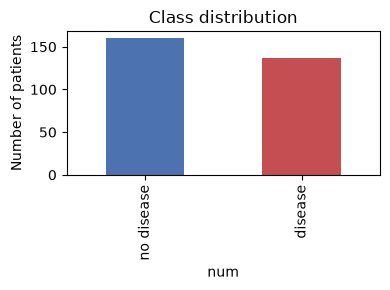

In [6]:
print(y.value_counts().rename({0: "no disease", 1: "disease"}))
print()
print(y.value_counts(normalize=True).rename({0: "no disease", 1: "disease"}).round(3))

fig, ax = plt.subplots(figsize=(4, 3))
y.value_counts().rename({0: "no disease", 1: "disease"}).plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of patients")
ax.set_title("Class distribution")
plt.tight_layout()
plt.show()

## 7. Preprocessing

The `ColumnTransformer` returned by `get_preprocessor(FEATURE_SET)` (defined in `data_cleaning.ipynb`) is reused unchanged here. It is only ever fitted inside a `Pipeline` together with each classifier (Section 9), never on the full dataset: `GridSearchCV` refits the scaler and encoder separately on each training fold during cross-validation, so no information from the validation folds leaks into preprocessing.

In [ ]:
# get_preprocessor(FEATURE_SET) is imported from data_cleaning.ipynb (Section 5
# above). It is only ever used inside a Pipeline (Section 9), fitted on
# training-fold data during cross-validation (Section 10) -- never fit here
# on the full dataset. This is just a sanity check on the transformed shape.
EXPECTED_N_TRANSFORMED = 13

n_transformed = get_preprocessor(FEATURE_SET).fit_transform(X).shape[1]
print(f"Preprocessed feature count for FEATURE_SET={FEATURE_SET!r} (on full data, for inspection only): {n_transformed}")
assert n_transformed == EXPECTED_N_TRANSFORMED, (
    f"Expected {EXPECTED_N_TRANSFORMED} transformed features for "
    f"FEATURE_SET={FEATURE_SET!r}, got {n_transformed}."
)

## 8. Fixed outer-fold construction

The proposal requires that all three arms are evaluated on the same outer cross-validation fold partitions (Section 3.5). Every patient is assigned a fold id once, stratified by the target, and the assignment is saved to `fold_id.csv`. If this file already exists, it is loaded and reused instead of being regenerated, so that Arm A, Arm B, and Arm C always evaluate the same patients in the same folds. `StratifiedKFold`, rather than a plain random split, is used because the classes are not perfectly balanced (160 vs 137), and stratification keeps the class ratio similar across folds. An MD5 hash of `fold_id.csv` is also written to `run_manifest.json`; Arm B and Arm C assert their loaded copy hashes to the same value, so a deleted, regenerated, or otherwise stale fold file is caught immediately rather than silently breaking comparability.

The loaded fold ids are also checked against `range(K_OUTER)` exactly, not just against `len(df)`: this project has already gone through a couple of different `K_OUTER` values (5, then 100, now 10), and a `fold_id.csv` left over from any earlier value has the right length (297) but the wrong set of fold ids. Length alone wouldn't catch that -- it would silently pass and then leave some fold ids with no validation patients in Section 10. On a mismatch, this notebook raises rather than deleting or regenerating the file itself: `fold_id.csv` must be regenerated deliberately (by removing the stale file and rerunning this notebook), and Arm B and Arm C must then be rerun afterwards, since they load the same file.

`run_manifest.json` also now records `feature_set`, `features`, `dropped_features`, `n_transformed_features`, `k_outer`, `k_inner`, and `random_state`, so a later reader (or Arm B/Arm C) can check this run's configuration without re-opening this notebook. The `fold_id_md5` key name is unchanged, since Arm B and Arm C read it by that name.

In [8]:
FOLD_FILE = os.path.join(PROJECT_ROOT, "fold_id.csv")

if os.path.exists(FOLD_FILE):
    fold_id = pd.read_csv(FOLD_FILE)["fold"].to_numpy()
    if len(fold_id) != len(df):
        raise ValueError(
            f"{FOLD_FILE} has {len(fold_id)} entries but the current dataset has {len(df)} rows; "
            "delete or regenerate the fold file before proceeding."
        )
    # Length matching alone isn't enough: a stale file from an earlier
    # K_OUTER (e.g. this project's earlier K_OUTER=5, RANDOM_STATE=42 run)
    # has the right length but the wrong fold ids, and would otherwise
    # silently produce empty outer validation folds in Section 10.
    found_folds = set(np.unique(fold_id).tolist())
    expected_folds = set(range(K_OUTER))
    if found_folds != expected_folds:
        raise ValueError(
            f"{FOLD_FILE} contains fold ids {sorted(found_folds)}, but K_OUTER={K_OUTER} "
            f"requires exactly {{0, ..., {K_OUTER - 1}}}. This looks like a fold file left over "
            "from a run with a different K_OUTER. Delete fold_id.csv and rerun this notebook to "
            "regenerate it, then rerun clinical_stratified_armB.ipynb and data_driven_armC.ipynb, "
            "since they load the same file and must stay on the same fold partition."
        )
    print(f"Loaded existing fold assignment from {FOLD_FILE}.")
else:
    skf = StratifiedKFold(n_splits=K_OUTER, shuffle=True, random_state=RANDOM_STATE)
    fold_id = np.empty(len(df), dtype=int)
    for k, (_, val_idx) in enumerate(skf.split(X, y)):
        fold_id[val_idx] = k
    pd.Series(fold_id, name="fold").to_csv(FOLD_FILE, index=False)
    print(f"Created new fold assignment and saved to {FOLD_FILE}.")

print("Fold sizes:", np.bincount(fold_id))
print("Positives per fold:", np.bincount(fold_id[y.values == 1]))

# Fold-file integrity guard (see Section 8): Arm B and Arm C assert against this hash.
fold_id_md5 = hashlib.md5(open(FOLD_FILE, "rb").read()).hexdigest()
MANIFEST_FILE = os.path.join(PROJECT_ROOT, "run_manifest.json")
manifest = {
    "fold_id_md5": fold_id_md5,
    "written_by": "global_model_armA.ipynb",
    "feature_set": FEATURE_SET,
    "features": used_features,
    "dropped_features": dropped_features,
    "n_transformed_features": n_transformed,
    "k_outer": K_OUTER,
    "k_inner": K_INNER,
    "random_state": RANDOM_STATE,
}
with open(MANIFEST_FILE, "w") as f:
    json.dump(manifest, f, indent=2)
print(f"fold_id.csv MD5: {fold_id_md5} (written to run_manifest.json)")

Loaded existing fold assignment from /Users/faye/Desktop/FIT2082/Research_heartDisease/FIT2082_Research/fold_id.csv.
Fold sizes: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2]
Positives per fold: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1]
fold_id.csv MD5: 4b90d0a595a2bcf87ea2273ae69eb371 (written to run_manifest.json)


## 8A. Feature-ranking stability check (diagnostic only)

This section checks whether the exploratory ranking behind `DROPPED_FEATURES` (`data_cleaning.ipynb`: `trestbps`, `chol`, `restecg`, `fbs`) is stable across the outer training folds. It is purely diagnostic: it never feeds back into `FEATURE_SET`, `FEATURE_GROUPS`, or any pipeline above or below it. The 9-feature subset stays fixed regardless of what this section finds.

For each outer fold, using only that fold's **training** patients (`fold_id != k`, never the validation patients), all 13 raw features are ranked by three independent methods:

- **(a) univariate p-value**: `chi2_contingency` for the categorical/binary features (`cp`, `slope`, `thal`, `restecg`, `sex`, `exang`, `fbs`, and `ca` treated as a 0-3 count), `f_oneway` (ANOVA F) for the continuous features (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`). Features are ranked by ascending p-value (rank 1 = smallest p-value = most significant).
- **(b) mutual information**: `mutual_info_classif` with an explicit `discrete_features` mask (True for the categorical/binary features above, including `ca`) and `random_state=RANDOM_STATE`. Ranked by descending mutual information.
- **(c) random-forest impurity importance**: a `RandomForestClassifier` (modest `n_estimators`, fixed `random_state=RANDOM_STATE`) fit directly on the raw (unencoded) features. Ranked by descending `feature_importances_`. **Caveat:** impurity importance is biased toward continuous and high-cardinality features (it tends to favour `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, and `cp` over low-cardinality binary features), so it is reported alongside, not instead of, the other two methods.

Per fold, a feature's *consensus rank* is the mean of its three method ranks that fold; the 4 features with the worst (highest) consensus rank that fold are its consensus bottom-4. Across the `K_OUTER` folds, `results/armA_feature_ranking_stability.csv` records, per feature: the median rank per method, the mean of those three medians (`mean_rank_across_methods`), the median univariate p-value, and the fraction of folds in which the feature lands in that fold's consensus bottom-4.

**Caveat on what "stable across folds" means here:** with `K_OUTER = 10` on 297 patients, each training fold excludes about 30 patients (the one validation fold), so any two training folds still share roughly 88-89% of their patients ((K_OUTER-2)/(K_OUTER-1) for equal-sized folds) -- down from ~99% back when `K_OUTER` was 100, but still a long way from independent samples. This check mainly shows the ranking is reasonably insensitive to which tenth of the patients is held out -- it does **not** show that the ranking would replicate on a genuinely new, independently collected sample. Treat the "stability" below as internal consistency, not external validation.

In [9]:
ALL_FEATURES = get_feature_list("all")
CATEGORICAL_FEATURES = ["cp", "restecg", "slope", "thal", "sex", "exang", "fbs", "ca"]
CONTINUOUS_FEATURES = [f for f in ALL_FEATURES if f not in CATEGORICAL_FEATURES]
DISCRETE_MASK = np.array([f in CATEGORICAL_FEATURES for f in ALL_FEATURES])

X_raw_all = df[ALL_FEATURES]
y_arr = y.to_numpy()

RF_RANK_N_ESTIMATORS = 200  # modest, fixed seed -- diagnostic only, not the modelling RF in Section 9

pvalue_history = {f: [] for f in ALL_FEATURES}
rank_history = {
    "univariate": {f: [] for f in ALL_FEATURES},
    "mutual_info": {f: [] for f in ALL_FEATURES},
    "random_forest": {f: [] for f in ALL_FEATURES},
}
bottom4_counts = {f: 0 for f in ALL_FEATURES}

for k in range(K_OUTER):
    train_mask = (fold_id != k)
    Xk = X_raw_all.loc[train_mask]
    yk = y_arr[train_mask]

    # (a) univariate p-values: chi2 for categorical/binary, ANOVA F for continuous.
    pvals = {}
    for feat in CATEGORICAL_FEATURES:
        table = pd.crosstab(Xk[feat], yk)
        _, p, _, _ = chi2_contingency(table)
        pvals[feat] = p
    for feat in CONTINUOUS_FEATURES:
        groups_by_class = [Xk.loc[yk == cls, feat] for cls in np.unique(yk)]
        _, p = f_oneway(*groups_by_class)
        pvals[feat] = p
    univ_rank = pd.Series(pvals).rank(method="average").reindex(ALL_FEATURES)

    # (b) mutual information.
    mi = mutual_info_classif(Xk.to_numpy(), yk, discrete_features=DISCRETE_MASK, random_state=RANDOM_STATE)
    mi_rank = pd.Series(-mi, index=ALL_FEATURES).rank(method="average")

    # (c) random-forest impurity importance (raw, unencoded features).
    rf = RandomForestClassifier(n_estimators=RF_RANK_N_ESTIMATORS, random_state=RANDOM_STATE)
    rf.fit(Xk.to_numpy(), yk)
    rf_rank = pd.Series(-rf.feature_importances_, index=ALL_FEATURES).rank(method="average")

    combined_rank = (univ_rank + mi_rank + rf_rank) / 3
    for feat in combined_rank.sort_values(ascending=False).index[:4]:
        bottom4_counts[feat] += 1

    for feat in ALL_FEATURES:
        pvalue_history[feat].append(pvals[feat])
        rank_history["univariate"][feat].append(univ_rank[feat])
        rank_history["mutual_info"][feat].append(mi_rank[feat])
        rank_history["random_forest"][feat].append(rf_rank[feat])

stability_rows = []
for feat in ALL_FEATURES:
    median_univ = float(np.median(rank_history["univariate"][feat]))
    median_mi = float(np.median(rank_history["mutual_info"][feat]))
    median_rf = float(np.median(rank_history["random_forest"][feat]))
    stability_rows.append({
        "feature": feat,
        "median_rank_univariate": median_univ,
        "median_rank_mutual_info": median_mi,
        "median_rank_random_forest": median_rf,
        "mean_rank_across_methods": float(np.mean([median_univ, median_mi, median_rf])),
        "median_pvalue": float(np.median(pvalue_history[feat])),
        "frac_folds_in_consensus_bottom4": bottom4_counts[feat] / K_OUTER,
        "dropped_in_selected_set": feat in DROPPED_FEATURES,
    })

stability_df = pd.DataFrame(stability_rows).sort_values("mean_rank_across_methods").reset_index(drop=True)
stability_df.to_csv(os.path.join(RESULTS_DIR, "armA_feature_ranking_stability.csv"), index=False)
print("Saved armA_feature_ranking_stability.csv")
stability_df.round(3)

Saved armA_feature_ranking_stability.csv


,feature,median_rank_univariate,median_rank_mutual_info,median_rank_random_forest,mean_rank_across_methods,median_pvalue,frac_folds_in_consensus_bottom4,dropped_in_selected_set
0,thal,1.0,1.0,2.0,1.333,0.000,0.00,False
1,cp,2.0,2.0,3.0,2.333,0.000,0.00,False
2,ca,3.0,3.0,4.0,3.333,0.000,0.00,False
3,oldpeak,4.0,4.0,5.0,4.333,0.000,0.00,False
4,thalach,5.0,8.0,2.0,5.000,0.000,0.00,False
5,exang,6.0,5.0,9.0,6.667,0.000,0.00,False
6,slope,7.0,7.0,10.0,8.000,0.000,0.00,False
7,chol,12.0,6.0,7.0,8.333,0.176,0.00,True
8,age,9.0,12.0,6.0,9.000,0.000,0.09,False
9,sex,8.0,9.0,11.0,9.333,0.000,0.92,False


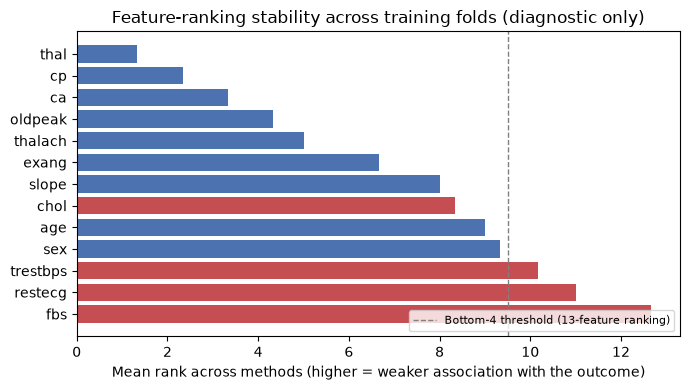

In [10]:
plot_order = stability_df.sort_values("mean_rank_across_methods", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
    plot_order["feature"], plot_order["mean_rank_across_methods"],
    color=["#C44E52" if d else "#4C72B0" for d in plot_order["dropped_in_selected_set"]],
)
ax.set_xlabel("Mean rank across methods (higher = weaker association with the outcome)")
ax.set_title("Feature-ranking stability across training folds (diagnostic only)")
ax.axvline(len(ALL_FEATURES) - 4 + 0.5, color="grey", linestyle="--", linewidth=1,
           label="Bottom-4 threshold (13-feature ranking)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Note: the numbers below are from the last run, at `K_OUTER = 100`.** Changing `K_OUTER` to 10 (Section 2) means `fold_id.csv` needs to be regenerated before this section is re-run, so these figures are stale until then -- kept here as the most recent finding rather than deleted.

**Honest read of the table above.** Three of the four dropped features are consistently at the weak end: `restecg` and `fbs` land in the consensus bottom-4 in 100% of the 100 training folds, and `trestbps` in 99%. All three also have clearly non-significant-to-marginal median univariate p-values (`fbs` median p = 1.0, `restecg` ≈ 0.009, `trestbps` ≈ 0.008) and the two worst (`fbs`, `restecg`) or near-worst (`trestbps`) mean ranks across methods (12.7, 11.0, 10.2 out of 13).

**`chol` is the exception, and it should be stated plainly rather than glossed over:** `chol` is in the consensus bottom-4 in **0%** of folds, with a mean rank of 8.3 out of 13 -- better than `age` (9.0), `sex` (9.3), and about tied with `slope` (8.0), none of which are dropped. Its univariate p-value is weak and not significant (median ≈ 0.18, consistent with dropping it on that criterion alone), but its mutual-information rank (median 6) and random-forest importance rank (median 7) are both mid-pack, pulling its combined rank up past several kept features. Separately, `sex` -- a kept feature -- lands in the consensus bottom-4 in 92% of folds, the second-highest rate of any feature after `restecg`/`fbs`.

So the four `DROPPED_FEATURES` are **not** uniformly the four weakest by this fold-wise consensus check: `restecg`, `fbs`, and `trestbps` are, `chol` is not (by mutual information and random-forest importance, though it is by the univariate test alone), and one kept feature (`sex`) ranks about as poorly as the dropped ones. Per the brief, the pre-specified list is **not** changed on the basis of this finding -- it was fixed in advance from a separate exploratory ranking on the full dataset, and this section exists only to check internal consistency of that ranking against the training folds. This discrepancy is worth flagging to whoever reviews the pre-specified list, since it means `chol`'s exclusion is better supported by its univariate p-value than by its multivariate association with the outcome.

**On what this does and doesn't demonstrate:** at the `K_OUTER = 100` this was run at, any two training folds shared roughly 291-292 of 297 patients (about 98% overlap); at the current `K_OUTER = 10` that overlap drops to roughly 88-89% (see the caveat above) -- still not independent samples, just somewhat less overlapping ones. Either way, this check mainly shows the ranking is insensitive to which patients are held out -- it does not show the ranking would replicate on an independently collected sample.

## 9. Model definitions and hyperparameter grids

Three classifiers are used: logistic regression (interpretable, linear), random forest (non-linear, tree-based), and a support vector classifier (linear or RBF kernel) as an additional comparator. Grids are kept small and are sized for a dataset this small (N ≈ 297 patients overall, so an inner-fold training split has roughly 240 patients):

- **Logistic regression**: `C` is searched over `np.logspace(-3, 2, 10)` (~0.001 to 100), with both l1 and l2 regularisation via the `liblinear` solver. As of scikit-learn 1.8, the `penalty="l1"/"l2"` strings are deprecated in favour of `l1_ratio` (`l1_ratio=0.0` = pure l2, `l1_ratio=1.0` = pure l1), which `liblinear` supports at both endpoints, so the grid searches `l1_ratio` instead -- the same two penalty types the old API expressed, without the deprecation warning.
- **Random forest**: `max_depth` is restricted to `[2, 3, 4, 5]`, `min_samples_leaf` to `[2, 4, 8]`, and `n_estimators` to `[50, 100]`. Shallow trees and larger leaf sizes are deliberate regularisation: with ~240 training patients per inner fold, deeper/unrestricted trees overfit rather than generalise.
- **SVM**: `C` is searched over a smaller `np.logspace(-3, 2, 6)` grid across `linear` and `rbf` kernels, with `gamma='scale'`. The estimator is wrapped in `CalibratedClassifierCV(SVC(), method='sigmoid', cv=5, ensemble=False)` rather than `SVC(probability=True)`, since the latter is deprecated as of scikit-learn 1.9; this keeps a `predict_proba` output (needed for ROC-AUC/PR-AUC scoring) without the deprecation warning.

The feature set is now fixed in advance by `FEATURE_SET` (Section 2) and `get_feature_list`/`get_preprocessor` (`data_cleaning.ipynb`, Section 5), rather than chosen inside cross-validation. `FEATURE_SELECTION_K` and the `SelectKBest(f_classif)` step it used to enable are retained in `build_pipeline` below purely for backward compatibility and are asserted `None` in Section 2: an in-CV `SelectKBest` step would pick features per training fold using that fold's own labels, which is a different (and weaker, more failure-prone) design than the pre-specified subset used here, and the two must not be stacked.

The same classifiers, grids, and tuning procedure are intended to be reused unchanged in Arm B and Arm C, so that any difference between arms reflects the stratification strategy rather than the modelling choices.

In [ ]:
def build_pipeline(estimator):
    """Chain the shared preprocessor, an optional feature-selection step,
    and a classifier. FEATURE_SELECTION_K (Section 2) toggles the
    SelectKBest step: None keeps every transformed feature; an int keeps
    only the k strongest by ANOVA F-value against the target. Kept for
    backward compatibility only -- it must stay None (asserted in Section
    2) now that FEATURE_SET fixes the feature subset in advance."""
    steps = [("preprocessor", get_preprocessor(FEATURE_SET))]
    if FEATURE_SELECTION_K is not None:
        steps.append(("select", SelectKBest(score_func=f_classif, k=FEATURE_SELECTION_K)))
    else:
        steps.append(("select", "passthrough"))
    steps.append(("clf", estimator))
    return Pipeline(steps)


models = {
    "logreg": (
        build_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
        {
            "clf__C": np.logspace(-3, 2, 10),   # ~0.001 to 100, log-spaced
            # l1_ratio=0.0 -> pure l2, l1_ratio=1.0 -> pure l1. scikit-learn
            # 1.8+ deprecated the old penalty="l1"/"l2" strings in favour of
            # l1_ratio (liblinear supports both endpoints); this searches
            # the same two penalty types the old API did.
            "clf__l1_ratio": [0.0, 1.0],
            "clf__solver": ["liblinear"],        # supports both l1 and l2 penalties
        },
    ),
    "rf": (
        build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
        {
            "clf__max_depth": [2, 3, 4, 5],       # shallow trees: N~297 overfits deeper ones
            "clf__min_samples_leaf": [2, 4, 8],
            "clf__n_estimators": [50, 100],
        },
    ),
    "svm": (
        # SVC(probability=True) is deprecated as of scikit-learn 1.9;
        # CalibratedClassifierCV(SVC(), ensemble=False) is the replacement
        # scikit-learn itself recommends for a predict_proba-compatible SVM.
        build_pipeline(CalibratedClassifierCV(
            SVC(random_state=RANDOM_STATE), method="sigmoid", cv=5, ensemble=False,
        )),
        {
            "clf__estimator__C": np.logspace(-3, 2, 6),
            "clf__estimator__kernel": ["linear", "rbf"],
            "clf__estimator__gamma": ["scale"],
        },
    ),
}

## 10. Nested cross-validation

For each model and each outer fold, hyperparameters are selected using `GridSearchCV` with an inner stratified cross-validation on the training portion of that fold only; the outer validation fold is never used during hyperparameter selection. ROC-AUC is used as the tuning criterion (`scoring="roc_auc"`) because it is threshold-independent. Accuracy, F1-score, ROC-AUC, PR-AUC (average precision), sensitivity (recall on the positive/disease class), and specificity (recall on the negative/no-disease class) are then computed on the held-out outer fold using the selected hyperparameters. Predicted class labels use a fixed probability threshold of 0.5, applied identically in every fold, model, and arm, so that thresholding does not become a source of variation between arms.

In [ ]:
fold_results = []
oof_rows = []
patient_id = df.index.to_numpy()

for name, (pipe, grid) in models.items():
    for k in range(K_OUTER):
        train, validation = (fold_id != k), (fold_id == k)

        # Hyperparameter selection uses only the training portion of this outer
        # fold; the outer validation fold is not seen until scoring below.
        inner = StratifiedKFold(n_splits=K_INNER, shuffle=True, random_state=RANDOM_STATE)
        search = GridSearchCV(pipe, grid, cv=inner, scoring="roc_auc", n_jobs=-1)
        search.fit(X[train], y[train])

        best = search.best_estimator_
        proba = best.predict_proba(X[validation])[:, 1]  # Predicted probability of the positive class (heart disease)
        pred  = (proba >= 0.5).astype(int)                # Fixed threshold, held constant across arms

        y_val = y[validation].to_numpy()
        # Specificity (true-negative rate) has no dedicated sklearn scorer,
        # so it's derived from the confusion matrix; sensitivity is the
        # standard recall on the positive class.
        tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        fold_results.append({
            "model": name,
            "fold": k,
            "accuracy": accuracy_score(y_val, pred),
            "f1": f1_score(y_val, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_val, proba),
            "pr_auc": average_precision_score(y_val, proba),
            "sensitivity": recall_score(y_val, pred, zero_division=0),
            "specificity": specificity,
            "best_params": search.best_params_,
        })

        for pid, yt, p, c in zip(patient_id[validation], y_val, proba, pred):
            oof_rows.append({
                "patient_id": int(pid), "fold": int(k), "y_true": int(yt),
                "model": name, "proba": float(p), "pred": int(c),
            })

fold_results_df = pd.DataFrame(fold_results)
print("Nested cross-validation complete:", len(fold_results_df), "model x fold rows")

## 11. Fold-level results

Individual outer-fold metrics are retained, in addition to the summary statistics in the next section, so that Arm B and Arm C can later be compared fold-by-fold rather than only through aggregate means.

In [ ]:
fold_results_df["feature_set"] = FEATURE_SET
fold_results_display = fold_results_df.drop(columns=["best_params"]).round(3)

fold_results_path = os.path.join(RESULTS_DIR, "armA_fold_results.csv")
fold_results_df.to_csv(fold_results_path, index=False)
print(f"Saved {os.path.basename(fold_results_path)}")
fold_results_display

## 12. Overall performance summary

Mean and standard deviation across the `K_OUTER` outer folds are reported for each model, rather than a single point estimate, so that both average performance and its variability across folds can be assessed.

In [ ]:
metric_cols = ["accuracy", "f1", "roc_auc", "pr_auc", "sensitivity", "specificity"]

results = (
    fold_results_df
    .groupby("model")[metric_cols]
    .agg(["mean", "std"])
)
results.columns = [f"{metric}_{stat}" for metric, stat in results.columns]
results = results.reset_index()
results["feature_set"] = FEATURE_SET

for _, row in results.iterrows():
    print(f"{row['model']:7s}"
          f" | ACC {row['accuracy_mean']:.3f} +/- {row['accuracy_std']:.3f}"
          f" | F1 {row['f1_mean']:.3f} +/- {row['f1_std']:.3f}"
          f" | ROC-AUC {row['roc_auc_mean']:.3f} +/- {row['roc_auc_std']:.3f}"
          f" | PR-AUC {row['pr_auc_mean']:.3f} +/- {row['pr_auc_std']:.3f}"
          f" | Sens {row['sensitivity_mean']:.3f} +/- {row['sensitivity_std']:.3f}"
          f" | Spec {row['specificity_mean']:.3f} +/- {row['specificity_std']:.3f}")

results_path = os.path.join(RESULTS_DIR, "armA_results.csv")
results.to_csv(results_path, index=False)
print(f"Saved {os.path.basename(results_path)}")
results.set_index("model").round(3)

## 13. Out-of-fold predictions

For every patient, the out-of-fold prediction from the one outer fold in which they were held out is retained, together with the patient identifier, fold id, true label, model name, predicted probability, and predicted class. This per-patient record is what allows Arm A, Arm B, and Arm C to be compared on identical patients rather than only through aggregate metrics.

In [ ]:
oof_df = pd.DataFrame(oof_rows)
oof_df["feature_set"] = FEATURE_SET

predictions_path = os.path.join(PREDICTIONS_DIR, "armA_predictions.csv")
oof_df.to_csv(predictions_path, index=False)
print(f"Saved {os.path.basename(predictions_path)}:", oof_df.shape)
oof_df.head()

## 14. Interpretation / notes

Three models (logistic regression, random forest, SVM) are compared; Arm A's purpose is to provide a comparison baseline rather than to select a single preferred classifier.

Feature set: modelling uses `FEATURE_SET` (Section 2), a fixed, pre-specified 9-feature subset defined once in `data_cleaning.ipynb`, rather than every raw feature or an in-CV `SelectKBest` selection. It drops `trestbps`, `chol`, `restecg`, and `fbs` -- the four features that consistently ranked weakest against the outcome in the exploratory ranking described in `data_cleaning.ipynb` and re-checked per training fold in Section 8A above. The older `SelectKBest(f_classif)` toggle (`FEATURE_SELECTION_K`) is superseded by this fixed subset and is asserted `None` in Section 2, since selecting features per training fold and fixing them in advance must not be combined.

Preprocessing changes from the previous version of this notebook (defined once in `data_cleaning.ipynb` and imported here):

- `ca` is standard-scaled as part of `continuous` rather than left as an unscaled passthrough count.
- The nominal `OneHotEncoder` now uses `drop='first'`, removing the exact multicollinearity between dummy columns that the previous full one-hot encoding produced.

For comparability with Arm B and Arm C:

- Arm B and Arm C should import `continuous`/`nominal`/`binary` and `get_preprocessor()` from `data_cleaning.ipynb` rather than keep their own local `passthrough`-based definitions, so all three arms stay aligned on feature representation. Arm B's existing exception of dropping `sex` from its subgroup feature matrix, and Arm C's additional standardisation of the passthrough block for clustering, are unaffected by this and remain arm-specific as previously documented. Both should now also drop `trestbps`, `chol`, `restecg`, and `fbs` to match Arm A's feature set, and should assert that `run_manifest.json`'s `feature_set` matches their own -- see the follow-up notes at the end of this notebook's change summary for what each arm still needs.
- `fold_id.csv`, created in Section 8, should continue to be loaded by Arm B and Arm C rather than regenerated, so all arms evaluate the same patients in the same folds.
- Arm C's k-prototypes clustering must still be fitted using only the training portion of each outer fold, so cluster assignment does not leak validation-fold information; this notebook does not perform any clustering or stratification, consistent with Arm A's role as the non-stratified baseline.